# Scaling, Reflection and Shear

## Purpose

Recognise three common 2D matrix behaviours by looking at where the basis vectors land.

In the previous notebooks, we learned two important ideas:

- the columns of a matrix tell us where the basis vectors go
- matrix-vector multiplication rebuilds a vector from those transformed basis vectors

This notebook applies those ideas to three named transformations:

- scaling
- reflection
- shear

The goal is not to memorise a long list of formulas.

The goal is to start seeing these matrices as simple geometric actions.

## Setup

We will use the standard basis vectors:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

and one example vector:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
= 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

Using the same vector throughout makes it easier to compare transformations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


e1 = np.array([1, 0])
e2 = np.array([0, 1])
v = np.array([2, 1])


def setup_axis(ax, title, xlim=(-2.5, 4.5), ylim=(-1.5, 3.5)):
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(
    ax,
    vector,
    origin=(0, 0),
    label=None,
    label_offset=(0.08, 0.08),
    linewidth=2,
    alpha=1.0,
    linestyle="-",
):
    origin = np.array(origin, dtype=float)
    vector = np.array(vector, dtype=float)

    ax.arrow(
        origin[0],
        origin[1],
        vector[0],
        vector[1],
        length_includes_head=True,
        head_width=0.08,
        head_length=0.12,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
    )

    if label is not None:
        end = origin + vector
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=11,
        )


def print_vector(name, vector):
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")


def show_transformation(A, title, xlim=(-2.5, 4.5), ylim=(-1.5, 3.5)):
    Ae1 = A @ e1
    Ae2 = A @ e2
    Av = A @ v

    print("A =")
    print(A)
    print()
    print_vector("Ae1", Ae1)
    print_vector("Ae2", Ae2)
    print_vector("Av ", Av)

    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    setup_axis(ax, title, xlim=xlim, ylim=ylim)

    # Faint original vectors for context.
    draw_vector(ax, e1, label="$e_1$", label_offset=(0.04, -0.22), alpha=0.35, linewidth=1.5)
    draw_vector(ax, e2, label="$e_2$", label_offset=(-0.25, 0.06), alpha=0.35, linewidth=1.5)
    draw_vector(ax, v, label="$v$", label_offset=(0.08, 0.08), alpha=0.35, linewidth=1.5)

    # Main transformed vectors.
    draw_vector(ax, Ae1, label="$Ae_1$", label_offset=(0.08, 0.06), linewidth=2.2)
    draw_vector(ax, Ae2, label="$Ae_2$", label_offset=(0.08, 0.06), linewidth=2.2)
    draw_vector(ax, Av, label="$Av$", label_offset=(0.08, 0.08), linewidth=2.5)

    plt.show()


def plot_comparison(cases, xlim=(-2.5, 4.5), ylim=(-1.5, 3.5)):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.ravel()

    for ax, (title, A) in zip(axes, cases):
        Ae1 = A @ e1
        Ae2 = A @ e2
        Av = A @ v

        setup_axis(ax, title, xlim=xlim, ylim=ylim)

        draw_vector(ax, e1, label="$e_1$", label_offset=(0.04, -0.22), alpha=0.25, linewidth=1.2)
        draw_vector(ax, e2, label="$e_2$", label_offset=(-0.25, 0.06), alpha=0.25, linewidth=1.2)
        draw_vector(ax, v, label="$v$", label_offset=(0.08, 0.08), alpha=0.25, linewidth=1.2)

        draw_vector(ax, Ae1, label="$Ae_1$", label_offset=(0.08, 0.06), linewidth=2.0)
        draw_vector(ax, Ae2, label="$Ae_2$", label_offset=(0.08, 0.06), linewidth=2.0)
        draw_vector(ax, Av, label="$Av$", label_offset=(0.08, 0.08), linewidth=2.2)

    plt.tight_layout()
    plt.show()

## A quick reminder: read the columns

For a 2×2 matrix:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

- the first column is where $\mathbf{e}_1$ lands
- the second column is where $\mathbf{e}_2$ lands

So if we can picture $A\mathbf{e}_1$ and $A\mathbf{e}_2$, we already understand the transformation.

The example vector then follows because:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

so:

$$
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
$$

The coefficients stay the same. The basis vectors move.

## Uniform scaling

A uniform scaling matrix stretches or shrinks both basis directions by the same amount.

For example:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 2
\end{bmatrix}
$$

Both columns point in the same directions as before, but both are twice as long.

A =
[[2 0]
 [0 2]]

Ae1 = [ 2.00,  0.00]
Ae2 = [ 0.00,  2.00]
Av  = [ 4.00,  2.00]


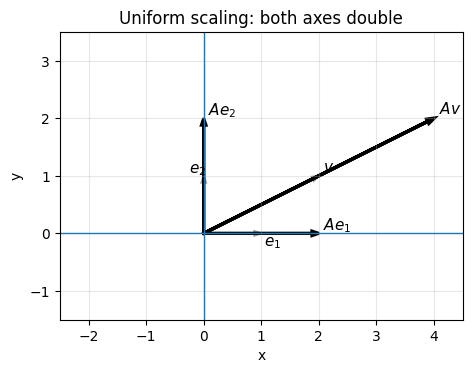

In [2]:
A = np.array([
    [2, 0],
    [0, 2],
])

show_transformation(A, title="Uniform scaling: both axes double")

The basis vectors keep their directions:

- $A\mathbf{e}_1 = [2, 0]$
- $A\mathbf{e}_2 = [0, 2]$

So the whole picture grows evenly.

The example vector keeps the same direction, but its length doubles.

## Non-uniform scaling

Now scale the two basis directions by different amounts:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 0.5
\end{bmatrix}
$$

The x-direction is stretched, while the y-direction is compressed.

A =
[[2.  0. ]
 [0.  0.5]]

Ae1 = [ 2.00,  0.00]
Ae2 = [ 0.00,  0.50]
Av  = [ 4.00,  0.50]


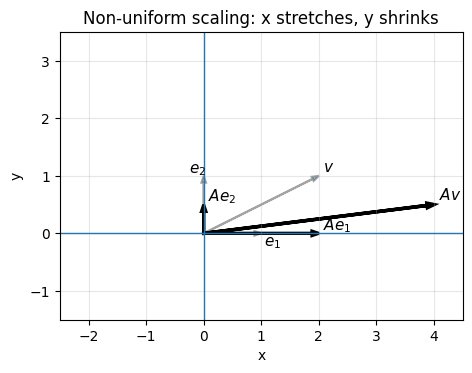

In [3]:
A = np.array([
    [2, 0],
    [0, 0.5],
])

show_transformation(A, title="Non-uniform scaling: x stretches, y shrinks")

Again, the columns are enough to describe the transformation:

- $A\mathbf{e}_1 = [2, 0]$
- $A\mathbf{e}_2 = [0, 0.5]$

The basis directions do not rotate or mix.

They just change length by different amounts, so the example vector changes both length and direction.

## Reflection across the x-axis

A reflection across the x-axis keeps the x-direction the same and flips the y-direction.

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

A =
[[ 1  0]
 [ 0 -1]]

Ae1 = [ 1.00,  0.00]
Ae2 = [ 0.00, -1.00]
Av  = [ 2.00, -1.00]


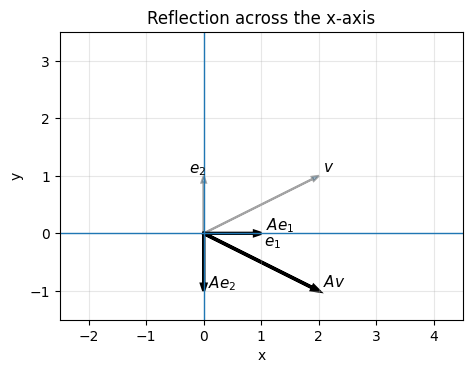

In [4]:
A = np.array([
    [1, 0],
    [0, -1],
])

show_transformation(A, title="Reflection across the x-axis")

Here:

- $A\mathbf{e}_1 = [1, 0]$, so $\mathbf{e}_1$ stays fixed
- $A\mathbf{e}_2 = [0, -1]$, so $\mathbf{e}_2$ flips direction

The example vector is mirrored below the x-axis.

## Reflection across the y-axis

A reflection across the y-axis flips the x-direction and keeps the y-direction the same.

$$
A =
\begin{bmatrix}
-1 & 0 \\
0 & 1
\end{bmatrix}
$$

A =
[[-1  0]
 [ 0  1]]

Ae1 = [-1.00,  0.00]
Ae2 = [ 0.00,  1.00]
Av  = [-2.00,  1.00]


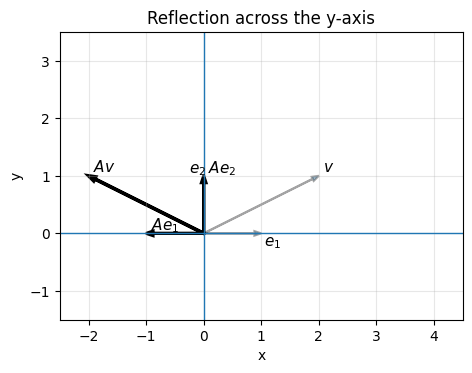

In [5]:
A = np.array([
    [-1, 0],
    [0, 1],
])

show_transformation(A, title="Reflection across the y-axis")

Here:

- $A\mathbf{e}_1 = [-1, 0]$, so $\mathbf{e}_1$ flips direction
- $A\mathbf{e}_2 = [0, 1]$, so $\mathbf{e}_2$ stays fixed

The example vector is mirrored to the left of the y-axis.

## Horizontal shear

A horizontal shear keeps the x-basis vector fixed, but gives the y-basis vector an x-component.

$$
A =
\begin{bmatrix}
1 & 1 \\
0 & 1
\end{bmatrix}
$$

This means:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
A\mathbf{e}_2 =
\begin{bmatrix}
1 \\
1
\end{bmatrix}
$$

A =
[[1 1]
 [0 1]]

Ae1 = [ 1.00,  0.00]
Ae2 = [ 1.00,  1.00]
Av  = [ 3.00,  1.00]


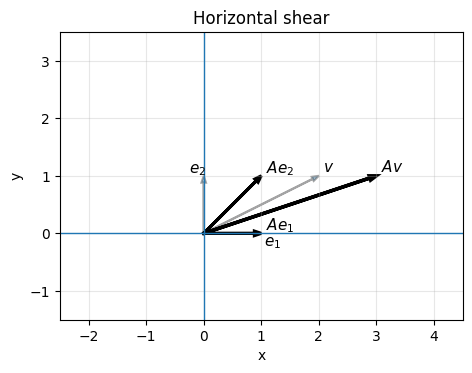

In [6]:
A = np.array([
    [1, 1],
    [0, 1],
])

show_transformation(A, title="Horizontal shear")

The y-coordinate stays the same, but points higher up are pushed farther sideways.

That is why this is called a horizontal shear.

## Vertical shear

A vertical shear keeps the y-basis vector fixed, but gives the x-basis vector a y-component.

$$
A =
\begin{bmatrix}
1 & 0 \\
1 & 1
\end{bmatrix}
$$

This means:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
1 \\
1
\end{bmatrix}
\qquad
A\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

A =
[[1 0]
 [1 1]]

Ae1 = [ 1.00,  1.00]
Ae2 = [ 0.00,  1.00]
Av  = [ 2.00,  3.00]


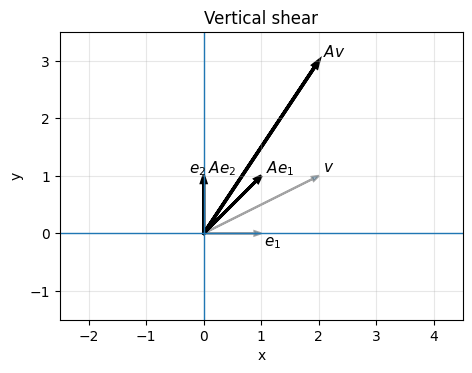

In [7]:
A = np.array([
    [1, 0],
    [1, 1],
])

show_transformation(A, title="Vertical shear")

The x-coordinate stays the same, but points farther to the right are pushed upward more.

That is why this is called a vertical shear.

## Comparison

Using the same vector each time makes the differences easier to see.

The plots below use shared axis limits so the comparisons stay visually honest.

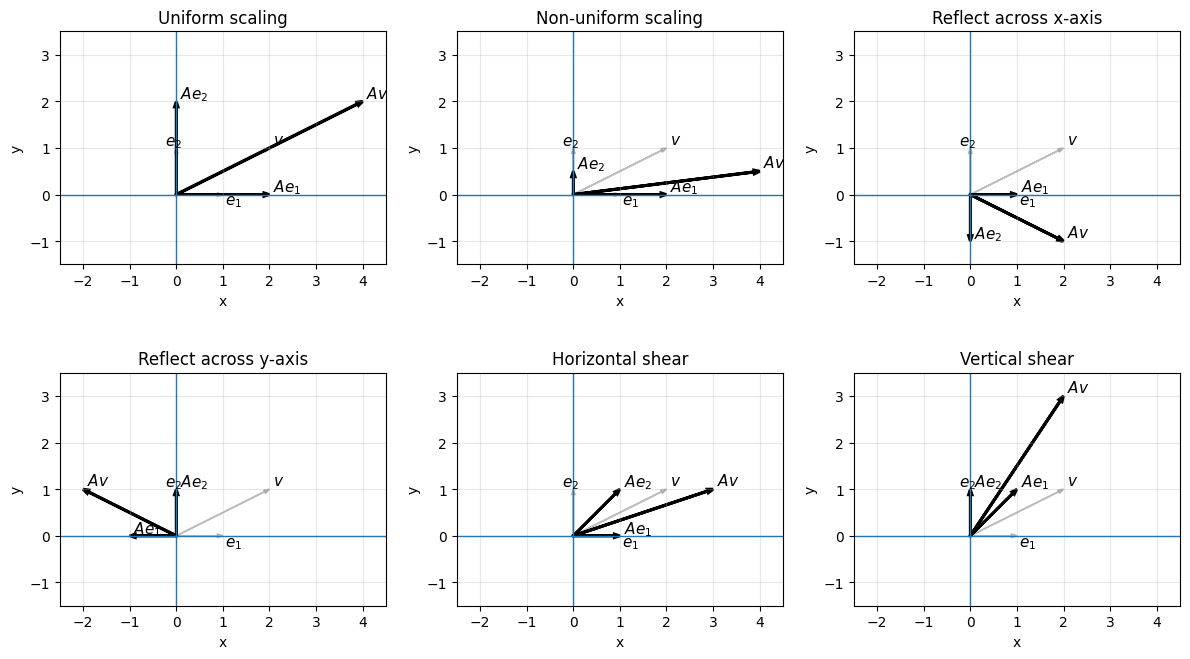

In [8]:
cases = [
    ("Uniform scaling", np.array([[2, 0], [0, 2]])),
    ("Non-uniform scaling", np.array([[2, 0], [0, 0.5]])),
    ("Reflect across x-axis", np.array([[1, 0], [0, -1]])),
    ("Reflect across y-axis", np.array([[-1, 0], [0, 1]])),
    ("Horizontal shear", np.array([[1, 1], [0, 1]])),
    ("Vertical shear", np.array([[1, 0], [1, 1]])),
]

plot_comparison(cases)

Each transformation has a simple basis-vector signature:

- **uniform scaling**: both basis vectors keep direction and change length by the same factor
- **non-uniform scaling**: both basis vectors keep direction, but change length by different factors
- **reflection**: one basis direction flips
- **shear**: one basis direction stays fixed while the other is slanted into it

## Summary

Scaling, reflection, and shear can all be recognised by looking at where the basis vectors land.

| Transformation | Matrix pattern | Basis-vector effect | Visual behaviour |
|---|---|---|---|
| Uniform scaling | $\begin{bmatrix}s & 0 \\ 0 & s\end{bmatrix}$ | both basis vectors keep direction and change length by the same factor | the whole picture grows or shrinks evenly |
| Non-uniform scaling | $\begin{bmatrix}s_x & 0 \\ 0 & s_y\end{bmatrix}$ | basis vectors keep direction but scale differently | stretching/compressing differs by axis |
| Reflection across x-axis | $\begin{bmatrix}1 & 0 \\ 0 & -1\end{bmatrix}$ | $\mathbf{e}_1$ stays fixed, $\mathbf{e}_2$ flips | points are mirrored above/below the x-axis |
| Reflection across y-axis | $\begin{bmatrix}-1 & 0 \\ 0 & 1\end{bmatrix}$ | $\mathbf{e}_1$ flips, $\mathbf{e}_2$ stays fixed | points are mirrored left/right of the y-axis |
| Horizontal shear | $\begin{bmatrix}1 & k \\ 0 & 1\end{bmatrix}$ | $\mathbf{e}_1$ stays fixed, $\mathbf{e}_2$ gains an x-component | higher points slide sideways |
| Vertical shear | $\begin{bmatrix}1 & 0 \\ k & 1\end{bmatrix}$ | $\mathbf{e}_2$ stays fixed, $\mathbf{e}_1$ gains a y-component | rightward points slide upward |

The central idea is still:

$$
A\mathbf{v} = x(A\mathbf{e}_1) + y(A\mathbf{e}_2)
$$

So named transformations are not a new kind of matrix.

They are familiar matrix actions that become easy to recognise once you know how to read the columns.

## Next step

Next, we can look at rotation matrices.